In [19]:
import matplotlib.pyplot as plt
from OptimalBattery.global_config import repo_dir,save_dir
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch
import matplotlib as mpl
mpl.rcParams["pdf.fonttype"] = 42
from scipy.stats import pearsonr



# simulations

In [20]:
sim_df = pd.read_csv(f"{repo_dir}/eval_tsvs/localization_sim_results.tsv", sep="\t")

In [21]:
palette = {
    "multi": "#D55E00",              
    "contrast_T": "#0072B2",        
    "contrast_percentage": "#009E73" 
}

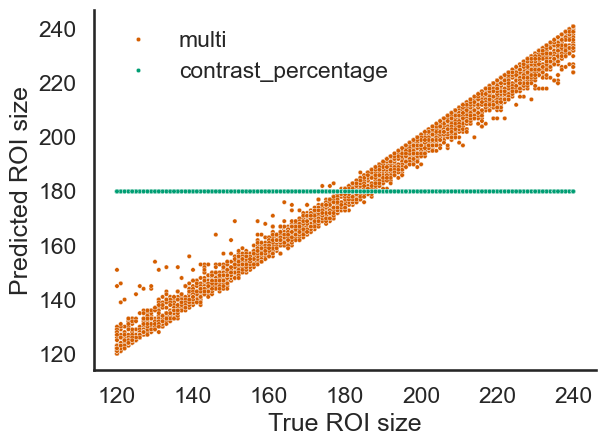

In [22]:
plot_df = sim_df[sim_df["type"].isin(["contrast_percentage", "multi"])]

plt.figure()
sns.scatterplot(
    data=plot_df,
    x="true_size", y="predicted_size",
    hue="type",
    palette=palette, s=10,rasterized = True
)

plt.xlabel("True ROI size")
plt.ylabel("Predicted ROI size")
sns.despine()
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(f"{save_dir}/single_vs_multi/sim_size.pdf")
plt.show()

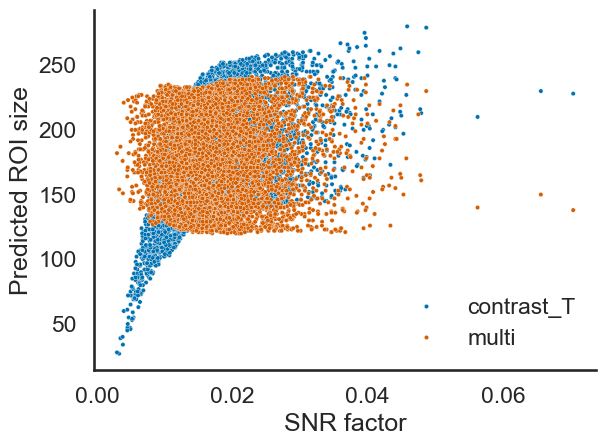

In [23]:
# Subset to relevant localizer types
plot_df = sim_df[sim_df["type"].isin(["contrast_T", "multi"])]

plt.figure()
sns.scatterplot(
    data=plot_df,
    x="snr_factor", y="predicted_size",
    hue="type",
    palette=palette, s=10,rasterized = True
)

plt.xlabel("SNR factor")
plt.ylabel("Predicted ROI size")
sns.despine()
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(f"{save_dir}/single_vs_multi/sim_fSNR.pdf")
plt.show()

In [24]:
df_multi = sim_df[sim_df["type"] == "multi"]
df_contrast = sim_df[sim_df["type"] == "contrast_T"]

r_multi, p_multi = pearsonr(df_multi["predicted_size"], df_multi["snr_factor"])
r_contrast, p_contrast = pearsonr(df_contrast["predicted_size"], df_contrast["snr_factor"])



print("Multi-task localizer:")
print(f"  r = {r_multi:.3f}, p = {p_multi:.3e}")

print("Single-contrast (T) localizer:")
print(f"  r = {r_contrast:.3f}, p = {p_contrast:.3e}")


Multi-task localizer:
  r = 0.017, p = 2.161e-01
Single-contrast (T) localizer:
  r = 0.500, p = 3.871e-315


C:\Users\barafat\AppData\Local\Temp\ipykernel_14004\3275376443.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


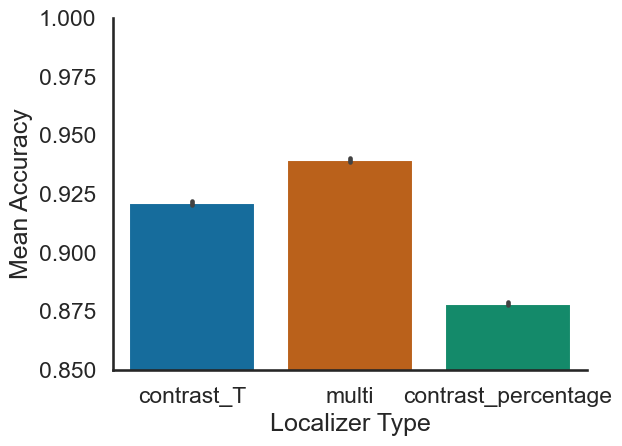

In [25]:
plt.figure()
sns.barplot(
    data=sim_df,
    x="type", y="accuracy",
    errorbar="se",
    palette=palette
)

plt.ylim(0.85, 1.0) 
plt.ylabel("Mean Accuracy")
plt.xlabel("Localizer Type")
sns.despine()
plt.tight_layout()
plt.savefig(f"{save_dir}/single_vs_multi/sim_accuracy.pdf")
plt.show()

# fMRI

In [26]:
real_df = pd.read_csv(f"{repo_dir}/eval_tsvs/localization_real_contrasts.tsv", sep="\t")


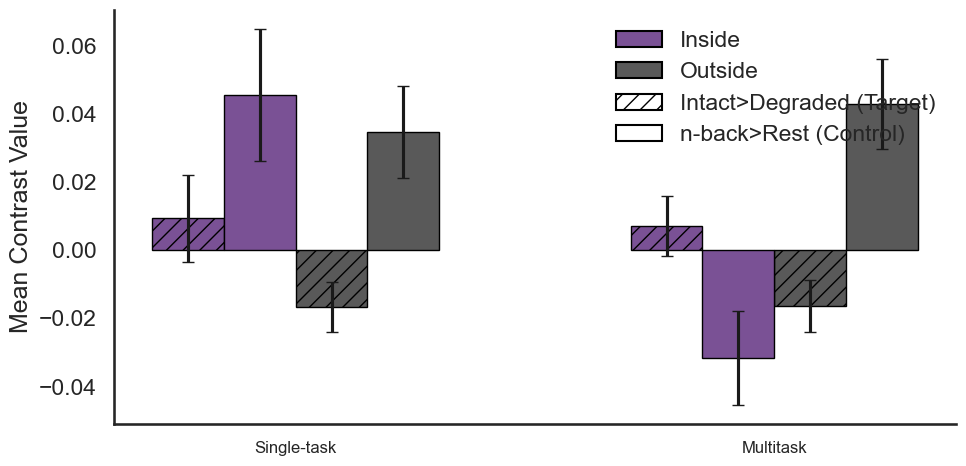

In [27]:
# --- Configuration ---
group_order   = ['Single-task', 'Multitask']
contrast_order = ['Intact>Degraded', 'n-back>Rest']
region_order   = ['Inside', 'Outside']

colors  = {'Inside': '#7A5195', 'Outside': '#595959'}
hatches = {'Intact>Degraded': '//', 'n-back>Rest': ''}

bar_width = 0.18
group_gap = 1.2

# --- Compute bar positions ---
x_positions = {}
x_labels, x_ticks = [], []
start = 0
for group in group_order:
    offsets = []
    for region_i, region in enumerate(region_order):
        for contrast_i, contrast in enumerate(contrast_order):
            key = (group, contrast, region)
            offset = (region_i * 2 + contrast_i - 1.5) * bar_width
            x = start + offset
            x_positions[key] = x
            offsets.append(x)
    x_labels.append(group)
    x_ticks.append(np.mean(offsets))
    start += group_gap

# Plot
sns.set(style="white", context="talk")
fig, ax = plt.subplots(figsize=(10,5))

for _, row in real_df.iterrows():
    key = (row['Localizer'], row['Contrast'], row['Region'])
    ax.bar(
        x_positions[key], row['Value'], width=bar_width,
        yerr=row['SEM'], capsize=4, color=colors[row['Region']],
        hatch=hatches[row['Contrast']], edgecolor='black', linewidth=1
    )

# Styling
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=12)
ax.set_ylabel('Mean Contrast Value')
sns.despine()

# Legend 
legend = [
    Patch(facecolor=colors['Inside'], edgecolor='black', label='Inside'),
    Patch(facecolor=colors['Outside'], edgecolor='black', label='Outside'),
    Patch(facecolor='white', edgecolor='black', hatch='//', label='Intact>Degraded (Target)'),
    Patch(facecolor='white', edgecolor='black', hatch='', label='n-back>Rest (Control)')
]
ax.legend(handles=legend, frameon=False, loc='upper right')

plt.tight_layout()
plt.savefig(f"{save_dir}/single_vs_multi/language_contrasts.pdf")
plt.show()